# Fama-French 五因子模型 — 学习笔记

本 notebook 是 [fama_french.ipynb](fama_french.ipynb) 的续篇：FF3 用市场、规模、价值三因子；
Fama & French (2015) 进一步加入**盈利(RMW)**与**投资(CMA)**两个因子，构成五因子模型。

**学习路径**：在 FF3 基础上构建 RMW / CMA → 五因子表现 → HML 是否冗余 → GRS 对比 FF3 vs FF5

---

## 一、理论公式 ↔ 代码变量

| 概念 | 公式 / 含义 | 代码变量 |
|------|------|----------|
| 五因子回归 | $R_i-r_f=\alpha+\beta_{MKT}MKT+\beta_{SMB}SMB+\beta_{HML}HML+\beta_{RMW}RMW+\beta_{CMA}CMA+\varepsilon$ | `sm.OLS` |
| 盈利因子 | $RMW=\overline{R_{robust}}-\overline{R_{weak}}$（高盈利 − 低盈利） | `ff['RMW']` |
| 投资因子 | $CMA=\overline{R_{conservative}}-\overline{R_{aggressive}}$（低扩张 − 高扩张） | `ff['CMA']` |
| 盈利代理 | ROE（净资产收益率，TTM） | `op` |
| 投资代理 | 总资产增长率（TTM） | `inv` |

## 二、与 FF3 的关系

- **RMW**：盈利能力强（robust）的公司，长期收益高于盈利弱（weak）的公司。
- **CMA**：投资扩张保守（conservative，总资产增速低）的公司，收益高于激进扩张（aggressive）的公司。
- **经典发现**：在 FF5 中，**HML 常常变得冗余**——它能被另外四个因子（尤其 RMW、CMA）线性解释。
  本笔记 Part 4 用「HML 对其余四因子回归看截距是否显著」验证，Part 5 再用 GRS 联合检验对比 FF3 / FF5。

## 三、原文与参考资料

- **原始论文**：Fama, E. F., & French, K. R. (2015). *A five-factor asset pricing model.* Journal of Financial Economics, 116(1), 1–22. [DOI:10.1016/j.jfineco.2014.10.010](https://doi.org/10.1016/j.jfineco.2014.10.010)
- **三因子原文**：Fama & French (1993). [DOI:10.1016/0304-405X(93)90023-5](https://doi.org/10.1016/0304-405X(93)90023-5)
- **官方因子数据与定义**：[Kenneth R. French Data Library](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html)
- **GRS 检验**：Gibbons, Ross & Shanken (1989). [DOI:10.2307/1913625](https://doi.org/10.2307/1913625)

> **数据口径**：与 FF3 一致（中证800 / 月频 / 上月末因子值防前视 / 米筐数据 / rf=2%）。
> SMB 按 FF5 规范取三套 2×3 排序（按 BM、OP、INV）的小盘−大盘**平均值**。
> RMW 用 ROE 近似营业盈利能力，CMA 用总资产增速，均为教学口径。

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

PROJECT_ROOT = None
for _c in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '../..')]:
    _r = os.path.abspath(_c)
    if os.path.isdir(os.path.join(_r, 'my_utils')):
        PROJECT_ROOT = _r
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('未找到项目根目录（需包含 my_utils 文件夹）')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from my_utils.rqdata import RqData
import rqdatac as rq

RqData()
print('米筐初始化完成')

米筐初始化完成


In [2]:
# ===================== Part 1：数据准备 =====================
start_date = '2021-01-01'
end_date = '2024-12-31'
rf_annual = 0.02
rf_monthly = rf_annual / 12

universe = rq.index_components('000906.XSHG', date=start_date)
print(f'中证800 成分股数: {len(universe)}')

# 行情：后复权日线 -> 月收益
px = rq.get_price(universe, start_date=start_date, end_date=end_date,
                  frequency='1d', fields='close', adjust_type='post')
m_close = px['close'].unstack('order_book_id').resample('M').last()
m_ret = m_close.pct_change()

# 四个分组变量：市值(SMB)、账面市值比(HML)、ROE(RMW)、总资产增速(CMA)
fac = rq.get_factor(universe,
                    ['market_cap_3', 'pb_ratio_ttm', 'return_on_equity_ttm', 'total_asset_growth_ratio_ttm'],
                    start_date=start_date, end_date=end_date)
mc = fac['market_cap_3'].unstack('order_book_id').resample('M').last()
bp = (1.0 / fac['pb_ratio_ttm'].unstack('order_book_id').resample('M').last()).where(lambda d: d > 0)
op = fac['return_on_equity_ttm'].unstack('order_book_id').resample('M').last()       # 盈利代理
inv = fac['total_asset_growth_ratio_ttm'].unstack('order_book_id').resample('M').last()  # 投资代理

# 市场组合：中证800 指数月收益
idx = rq.get_price('000906.XSHG', start_date=start_date, end_date=end_date,
                   frequency='1d', fields='close')
idx_m = idx['close'].droplevel('order_book_id').resample('M').last().pct_change()

print(f'月份数: {m_ret.shape[0]}, 股票数: {m_ret.shape[1]}')
fac.head(3)

中证800 成分股数: 800


月份数: 48, 股票数: 800


market_cap_3  pb_ratio_ttm  return_on_equity_ttm  \
order_book_id date                                                             
603883.XSHG   2021-01-04  2.60893695e+10    6.75457119            0.15986453   
              2021-01-05  2.72869545e+10    7.06462749            0.15986453   
              2021-01-06  2.76834247e+10    7.16727412            0.15986453   

                          total_asset_growth_ratio_ttm  
order_book_id date                                      
603883.XSHG   2021-01-04                    0.16566552  
              2021-01-05                    0.16566552  
              2021-01-06                    0.16566552

In [3]:
# ===================== Part 2：2×3 排序构建五因子 =====================
# 思路：Size 维度按市值中位数分 2 组；第二维度按 30%/70% 分位分 3 组(L/M/H)。
# 一次排序得到 6 个市值加权组合，可派生：
#   spread = (SH+BH)/2 - (SL+BL)/2  （高 - 低）
#   smb    = (SL+SM+SH)/3 - (BL+BM+BH)/3  （小 - 大）
# FF5 规范：SMB = 三套排序(BM/OP/INV) 的 smb 平均。
# 额外：保存按 BM 排序的 6 个组合（SL..BH），作为 Part 5 GRS 检验的测试资产。

common = m_ret.columns
for d in (mc, bp, op, inv):
    common = common.intersection(d.columns)
m_ret_a = m_ret[common]
mc_a, bp_a, op_a, inv_a = mc[common], bp[common], op[common], inv[common]
months = m_ret_a.index


def sort_2x3(size, second, ret):
    """size × second 的 2×3 市值加权排序，返回 (spread, smb, 6组合字典)。"""
    mask = size.notna() & second.notna() & ret.notna() & (size > 0)
    size, second, ret = size[mask], second[mask], ret[mask]
    if len(size) < 30:
        return np.nan, np.nan, {}
    big = size >= size.median()
    q30, q70 = second.quantile(0.3), second.quantile(0.7)
    low, high = second <= q30, second >= q70
    mid = ~low & ~high

    def vw(sel):
        if sel.sum() == 0:
            return np.nan
        w = size[sel]
        return float((ret[sel] * w).sum() / w.sum())

    six = dict(SL=vw(~big & low), SM=vw(~big & mid), SH=vw(~big & high),
               BL=vw(big & low), BM=vw(big & mid), BH=vw(big & high))
    spread = (six['SH'] + six['BH']) / 2 - (six['SL'] + six['BL']) / 2     # 高 - 低
    smb = (six['SL'] + six['SM'] + six['SH']) / 3 - (six['BL'] + six['BM'] + six['BH']) / 3
    return spread, smb, six


records, port6 = [], []
for i in range(1, len(months)):
    t, t_prev = months[i], months[i - 1]
    size = mc_a.loc[t_prev]
    ret = m_ret_a.loc[t]
    hml, smb_bm, six_bm = sort_2x3(size, bp_a.loc[t_prev], ret)    # 价值排序
    rmw, smb_op, _ = sort_2x3(size, op_a.loc[t_prev], ret)        # 盈利排序
    cma_sp, smb_inv, _ = sort_2x3(size, inv_a.loc[t_prev], ret)   # 投资排序
    if np.isnan([hml, rmw, cma_sp]).any():
        continue
    cma = -cma_sp                                          # 保守(低增速) - 激进(高增速)
    smb = np.nanmean([smb_bm, smb_op, smb_inv])            # FF5 规范：三套排序平均
    records.append(dict(month=t, SMB=smb, HML=hml, RMW=rmw, CMA=cma))
    port6.append(dict(month=t, **six_bm))

ff = pd.DataFrame(records).set_index('month')
ff['MKT'] = idx_m.reindex(ff.index) - rf_monthly
ff = ff.dropna()
port6 = pd.DataFrame(port6).set_index('month').reindex(ff.index)   # 6 个 size×BM 测试组合
print(f'有效月份数: {len(ff)}')
ff[['MKT', 'SMB', 'HML', 'RMW', 'CMA']].head()

有效月份数: 47


,MKT,SMB,HML,RMW,CMA
month,,,,,
2021-02-28,-0.00325590,0.03814319,0.07598413,-0.01392791,0.02287359
2021-03-31,-0.04765652,0.05199793,0.08331338,-0.00274414,0.03747437
2021-04-30,0.01822046,-0.00105779,-0.06558467,0.02227637,-0.02422336
2021-05-31,0.03823437,-0.00649604,-0.00832666,-0.03387015,0.01534509
2021-06-30,-0.01466116,0.00572608,-0.01955744,-0.01830609,0.02159441


=== 因子月均收益 t 检验 ===
 因子      月均      年化   年化波动      t值
MKT -0.0058 -0.0698 0.1897 -0.7280
SMB  0.0063  0.0756 0.1224  1.2220
HML  0.0127  0.1529 0.1853  1.6331
RMW -0.0054 -0.0653 0.1170 -1.1052
CMA  0.0057  0.0688 0.1009  1.3495


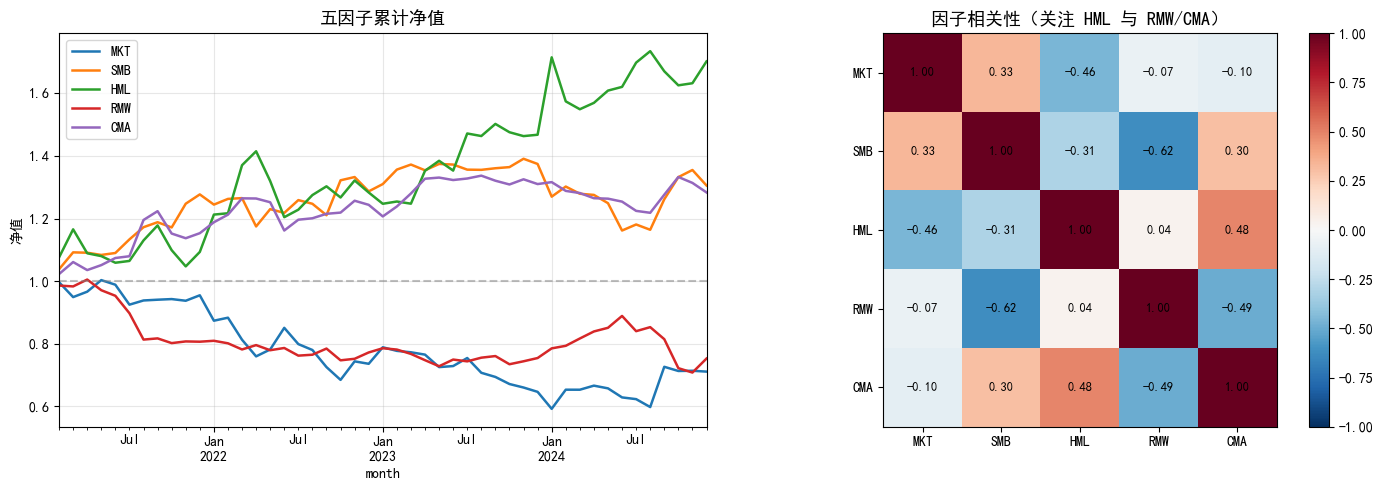

In [4]:
# ===================== Part 3：五因子表现与相关性 =====================
factors = ['MKT', 'SMB', 'HML', 'RMW', 'CMA']

print('=== 因子月均收益 t 检验 ===')
summary = []
for f in factors:
    x = ff[f]
    t_stat = x.mean() / (x.std(ddof=1) / np.sqrt(len(x)))
    summary.append(dict(因子=f, 月均=x.mean(), 年化=x.mean() * 12,
                        年化波动=x.std(ddof=1) * np.sqrt(12), t值=t_stat))
print(pd.DataFrame(summary).to_string(index=False, float_format=lambda v: f'{v:.4f}'))

nav = (1 + ff[factors]).cumprod()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
nav.plot(ax=axes[0], linewidth=1.8)
axes[0].set_title('五因子累计净值', fontsize=13)
axes[0].axhline(1, color='gray', ls='--', alpha=0.5)
axes[0].set_ylabel('净值'); axes[0].grid(True, alpha=0.3); axes[0].legend()

corr = ff[factors].corr()
im = axes[1].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_xticks(range(5)); axes[1].set_xticklabels(factors)
axes[1].set_yticks(range(5)); axes[1].set_yticklabels(factors)
for r in range(5):
    for c in range(5):
        axes[1].text(c, r, f'{corr.iloc[r, c]:.2f}', ha='center', va='center', fontsize=9)
axes[1].set_title('因子相关性（关注 HML 与 RMW/CMA）', fontsize=13)
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

In [5]:
# ===================== Part 4：HML 冗余检验 =====================
# 经典：把 HML 对 MKT/SMB/RMW/CMA 回归，若截距 α 不显著，则 HML 被其余因子张成（冗余）。
print('=== HML 冗余检验：HML ~ MKT + SMB + RMW + CMA ===')
y = ff['HML']
X = sm.add_constant(ff[['MKT', 'SMB', 'RMW', 'CMA']])
m = sm.OLS(y, X).fit()
print(f'截距 alpha(月) = {m.params["const"]:.4f}, t = {m.tvalues["const"]:.2f}, p = {m.pvalues["const"]:.3f}')
print(f'R^2 = {m.rsquared:.3f}')
print('系数:'); print(m.params.round(3).to_string())
verdict = 'HML 冗余（截距不显著，被其余四因子解释）' if m.pvalues['const'] > 0.05 else 'HML 仍有独立 alpha（不冗余）'
print(f'结论: {verdict}')

print('\n=== 各因子对其余四因子回归的截距显著性 ===')
rows = []
for f in ['SMB', 'HML', 'RMW', 'CMA']:
    others = [x for x in ['MKT', 'SMB', 'HML', 'RMW', 'CMA'] if x != f]
    mm = sm.OLS(ff[f], sm.add_constant(ff[others])).fit()
    rows.append(dict(因子=f, 截距月=mm.params['const'], t值=mm.tvalues['const'],
                     是否冗余='是' if mm.pvalues['const'] > 0.05 else '否'))
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f'{v:.4f}'))

=== HML 冗余检验：HML ~ MKT + SMB + RMW + CMA ===
截距 alpha(月) = 0.0088, t = 1.52, p = 0.137
R^2 = 0.533
系数:
const    0.009
MKT     -0.279
SMB     -0.490
RMW      0.188
CMA      1.125
结论: HML 冗余（截距不显著，被其余四因子解释）

=== 各因子对其余四因子回归的截距显著性 ===
 因子     截距月      t值 是否冗余
SMB  0.0053  1.3712    是
HML  0.0088  1.5165    是
RMW -0.0004 -0.0936    是
CMA -0.0012 -0.3596    是


In [6]:
# ===================== Part 5：GRS 联合检验 — FF3 vs FF5 =====================
# 用 6 个 size×BM 组合作测试资产，比较 FF3 与 FF5 谁能把"全部 α 联合压到 0"。
# GRS = (T-N-K)/N · (a'Σ⁻¹a)/(1 + f̄'Ω⁻¹f̄) ~ F(N, T-N-K)。p 值越大模型越完整。
from scipy import stats


def grs_test(excess_assets, factors):
    F = factors.values
    T, K = F.shape
    N = excess_assets.shape[1]
    Xc = sm.add_constant(F)
    alphas, resid = [], []
    for c in excess_assets.columns:
        mm = sm.OLS(excess_assets[c].values, Xc).fit()
        alphas.append(mm.params[0]); resid.append(mm.resid)
    a = np.array(alphas)
    E = np.column_stack(resid)
    Sigma = E.T @ E / T
    fbar = F.mean(axis=0)
    Fd = F - fbar
    Omega = np.atleast_2d(Fd.T @ Fd / T)
    sh2 = float(fbar @ np.linalg.inv(Omega) @ fbar)
    grs = (T - N - K) / N * float(a @ np.linalg.inv(Sigma) @ a) / (1 + sh2)
    return grs, stats.f.sf(grs, N, T - N - K), N, len(F)


ex6 = (port6 - rf_monthly).dropna()
common_idx = ex6.index.intersection(ff.index)
ex6 = ex6.loc[common_idx]
g_ff3 = grs_test(ex6, ff.loc[common_idx, ['MKT', 'SMB', 'HML']])
g_ff5 = grs_test(ex6, ff.loc[common_idx, ['MKT', 'SMB', 'HML', 'RMW', 'CMA']])
print(f'测试资产 N={g_ff5[2]}（6 个 size×BM 组合），样本期 T={g_ff5[3]}')
print('=== GRS 联合检验（H0: 6 组合 α 全为 0）===')
for name, g in [('FF3', g_ff3), ('FF5', g_ff5)]:
    verdict = '拒绝 H0（仍有未解释 α）' if g[1] < 0.05 else '不拒绝 H0（解释较完整）'
    print(f'{name}: GRS={g[0]:.3f}, p={g[1]:.4f}  ->  {verdict}')
print('\n解读：p 值越大越好。若 FF5 的 p 高于 FF3，说明加入 RMW/CMA 进一步降低了联合定价误差；'
      '若二者接近，则在本样本上盈利/投资因子的增量解释力有限（与所选股票池、区间有关）。')

测试资产 N=6（6 个 size×BM 组合），样本期 T=47
=== GRS 联合检验（H0: 6 组合 α 全为 0）===
FF3: GRS=2.815, p=0.0229  ->  拒绝 H0（仍有未解释 α）
FF5: GRS=1.461, p=0.2192  ->  不拒绝 H0（解释较完整）

解读：p 值越大越好。若 FF5 的 p 高于 FF3，说明加入 RMW/CMA 进一步降低了联合定价误差；若二者接近，则在本样本上盈利/投资因子的增量解释力有限（与所选股票池、区间有关）。


## 四、学习小结

1. **因子构建（Part 2）**：用通用的 `sort_2x3` 对市值×{账面市值比、ROE、总资产增速} 三套排序，分别得到 HML、RMW、CMA；SMB 取三套排序小盘−大盘的平均（FF5 规范）。
2. **盈利与投资（Part 3）**：RMW 做多高 ROE、做空低 ROE；CMA 做多低资产扩张、做空高扩张。观察它们的年化收益与显著性，以及与 HML 的相关性。
3. **HML 冗余（Part 4）**：把 HML 对其余四因子回归，若截距 α 不显著，说明 HML 被 RMW/CMA 等张成——这正是 Fama-French (2015) 在美股市场的著名发现。A 股样本结论可能不同，值得对照思考。
4. **GRS 对比（Part 5）**：用 GRS 联合检验在同一组测试资产上比较 FF3 与 FF5，从"联合定价误差"角度判断盈利/投资因子是否带来增量解释力。
5. **模型取舍**：因子越多解释力通常越强，但要警惕**冗余因子**与**过拟合**；冗余回归、GRS 检验都是判断「该不该加这个因子」的工具。

**与 Barra 的区别**：FF 系列是**定价检验**（少数可交易因子组合，检验能否解释收益）；
[barra_use3.ipynb](barra_use3.ipynb) 的 Barra CNE5 是**风险模型**（数十个因子，目标是预测协方差与做收益归因），二者目的不同。